Clustering of features extracted from tiles with UNI2.\
TILES: originals.\
Conda environment: `cluster_n_class`.

---
# 0. - Imports and paths

In [25]:
import os
import pandas as pd
import numpy as np
import matplotlib.font_manager as fm
%matplotlib inline
import matplotlib.pyplot as plt
import pickle
import matplotlib.image as mpimg
from collections import defaultdict
from sklearn.decomposition import PCA
import json
import math
from PIL import Image, ImageDraw

Setting the working directory.

In [26]:
os.chdir("/disk2/user/gabgam/the_project/4_features_clustering/")
print(os.getcwd())

/disk2/user/gabgam/the_project/4_features_clustering


In [27]:
# Fetch DM Sans font file from https://github.com/google/fonts/blob/main/ofl/dmsans/DMSans%5Bopsz%2Cwght%5D.ttf or, better, https://fonts.google.com/specimen/DM+Sans
font_path = "../fonts/static/DMSans-Medium.ttf" 

# Add font to matplotlib
try:
    fm.fontManager.addfont(font_path)
    plt.rcParams['font.family'] = 'DM Sans'
except RuntimeError as e:
    print(f"Failed to load font: {e}")

Model name and normalisation method in analysis.

In [28]:
MODEL = "UNI2-h"
NORMALISATION_NAME = "ORIGINAL WSI"

All the paths to the files for this step of the analysis.

In [29]:
# WIDTH = None    # This is only for KimiaNet, for the other models the variable must be set to None 
# PATH_TO_SINGLE_PICKLES = f"../3_features_extraction/output/{MODEL}/satac_C1_v3_allspots_&_visium_2022_FF_WG_10X_img_not_changed_allspots/"

# PATH_TO_VISIUM_WSI = "../data/visium_2022_FF_WG/input_files/Visium_Human_Breast_Cancer_image.tif"
# PATH_TO_VISIUM_TISSUE_COORDINATES_LIST = "../data/visium_2022_FF_WG/output_n_suppl_files/spatial/tissue_positions_list.csv"
# PATH_TO_VISIUM_NECROSIS_SELECTED_SPOTS = None
# PATH_TO_VISIUM_SCALE_FACTOR_JSON = "../data/visium_2022_FF_WG/output_n_suppl_files/spatial/scalefactors_json.json"
# VISIUM_WSI_TRASPARENCY = None

# PATH_TO_SATAC_WSI = "../data/spatial_atac/modified_images/BCSA4_A2_sATAC_C1_adjacent-Spot000001_v3_newrot_newcrop_realcolors_nofakescaling.jpg"
# PATH_TO_SATAC_TISSUE_COORDINATES_LIST = "../1_tiling/output/satac_C1/satac_C1_v3_allspots_fake_tissue_position_list.csv"
# SATAC_WSI_TRASPARENCY = 200

# COMPARISON = "satac_C1_v3_allspots_&_visium_2022_FF_WG_10X_img_not_changed_allspots"

In [30]:
WIDTH = None # This is only for KimiaNet, for the other models the variable must be set to None
PATH_TO_SINGLE_PICKLES = f"../3_features_extraction/output/{MODEL}/satac_C1_v3_allspots_&_visium_FFPE_dcis_idc_10X_img_not_changed_allspots/"

PATH_TO_VISIUM_WSI = "../data/visium_ffpe/input_files/Visium_FFPE_Human_Breast_Cancer_image.jpg"
PATH_TO_VISIUM_TISSUE_COORDINATES_LIST = "../data/visium_ffpe/output_n_suppl_files/spatial/tissue_positions_list.csv"
PATH_TO_VISIUM_NECROSIS_SELECTED_SPOTS = "../data/visium_ffpe/output_n_suppl_files/spatial/Visium_FFPE_selected_necrosis_spots_v2.csv"
# PATH_TO_VISIUM_NECROSIS_SELECTED_SPOTS = None
PATH_TO_VISIUM_SCALE_FACTOR_JSON = "../data/visium_ffpe/output_n_suppl_files/spatial/scalefactors_json.json"
VISIUM_WSI_TRASPARENCY = None

PATH_TO_SATAC_WSI = "../data/spatial_atac/modified_images/BCSA4_A2_sATAC_C1_adjacent-Spot000001_v3_newrot_newcrop_realcolors_nofakescaling.jpg"
PATH_TO_SATAC_TISSUE_COORDINATES_LIST = "../1_tiling/output/satac_C1/satac_C1_v3_allspots_fake_tissue_position_list.csv"
SATAC_WSI_TRASPARENCY = 200

COMPARISON = "satac_C1_v3_allspots_&_visium_FFPE_dcis_idc_10X_img_not_changed_allspots"

Number of clusters for performing clustering

In [31]:
NUMBER_OF_CLUSTERS = 6

Path to reference image and it's name.

In [32]:
# path to the target image
PATH_TO_REFERENCE = "../2_image_normalisation/reference_images/reference_full.jpeg"
# `TARGET_IS_<filename>`
TARGET_IS = "target_is_reference_full"

Defining the path to the figures.

In [33]:
if WIDTH:
    PATH_TO_FIGURES = f"figures/{MODEL}/{COMPARISON}_width{WIDTH}/on_individual_samples/{NUMBER_OF_CLUSTERS}_clusters/"
    PATH_TO_SAVING_OUTPUT = f"output/{MODEL}/{COMPARISON}_width{WIDTH}/on_individual_samples/{NUMBER_OF_CLUSTERS}_clusters/"
else:
    PATH_TO_FIGURES = f"./figures/{MODEL}/{COMPARISON}/on_individual_samples/{NUMBER_OF_CLUSTERS}_clusters/"
    PATH_TO_SAVING_OUTPUT = f"output/{MODEL}/{COMPARISON}/on_individual_samples/{NUMBER_OF_CLUSTERS}_clusters/"

os.makedirs(PATH_TO_FIGURES, exist_ok=True)
os.makedirs(PATH_TO_SAVING_OUTPUT, exist_ok=True)

# 1. - Importing the extracted features

First of all, let's see all the MERGED `.pickle` files inside the folder of the saved features.

In [34]:
if WIDTH:
    selected_pickle_names = [i for i in os.listdir(PATH_TO_SINGLE_PICKLES) if i.endswith(f'um_{NORMALISATION_NAME}_width{WIDTH}.pickle')]
else:
    selected_pickle_names = [i for i in os.listdir(PATH_TO_SINGLE_PICKLES) if i.endswith(f'um_{NORMALISATION_NAME}.pickle')]

print(f"{len(selected_pickle_names)} .pickle files inside the folder.\n")
print(selected_pickle_names)

4 .pickle files inside the folder.

['satac_C1_&_v3_allspots_&_target_is_reference_full_100um_ORIGINAL WSI.pickle', 'satac_C1_&_v3_allspots_&_target_is_reference_full_68um_ORIGINAL WSI.pickle', 'visium_FFPE_dcis_idc_10X_&_img_not_changed_allspots_&_target_is_reference_full_100um_ORIGINAL WSI.pickle', 'visium_FFPE_dcis_idc_10X_&_img_not_changed_allspots_&_target_is_reference_full_68um_ORIGINAL WSI.pickle']


And let's choose the first file to visualise and extract the normalisation name from it.

In [35]:
TILE_SIZE = 100
SPOT_SIZE = 68

Reading the tissue coordinates list files.

In [36]:
satac_coord_df = pd.read_csv(PATH_TO_SATAC_TISSUE_COORDINATES_LIST)

visium_coord_df = pd.read_csv(PATH_TO_VISIUM_TISSUE_COORDINATES_LIST, header=None, names = ["barcode", "in_tissue", "array_row", "array_col", "pxl_row", "pxl_col"])

Tile sizes for sATAC.

In [37]:
# 68 μm
satac_scale_factor_spot_size = float(satac_coord_df.iloc[0]["diameter"])
print("68μm-spot's diameter in pixels: ~", satac_scale_factor_spot_size, "px")

# 100 μm
satac_scale_factor_tile_size = (satac_scale_factor_spot_size * TILE_SIZE) / SPOT_SIZE
print("100μm-tile's size in pixels: ~", math.floor(satac_scale_factor_tile_size), "px")

68μm-spot's diameter in pixels: ~ 377.86462 px
100μm-tile's size in pixels: ~ 555 px


Tile sizes for Visium.

In [38]:
# Load the manual_alignment.json file
with open(PATH_TO_VISIUM_SCALE_FACTOR_JSON, 'r') as f:
    visium_json = json.load(f)

# 68 μm
visium_scale_factor_spot_size = float(visium_json["spot_diameter_fullres"])
print("68μm-spot's diameter in pixels: ~", visium_scale_factor_spot_size, "px")

# 100 μm
visium_scale_factor_tile_size = (visium_scale_factor_spot_size * TILE_SIZE) / SPOT_SIZE
print("100μm-tile's size in pixels: ~", math.floor(visium_scale_factor_tile_size), "px")

68μm-spot's diameter in pixels: ~ 188.56998854645946 px
100μm-tile's size in pixels: ~ 277 px


Importing the WSIs and setting the trasparency through the alpha value. [Tutorial](https://note.nkmk.me/en/python-pillow-putalpha/).\
Why do we need to set the trasparency? Because some WSIs, like the sATAC ones, are very bright and the colors drawn on them in the clustering step tend to be covered by the actual color and brightness of the WSI on the bottom.

In [39]:
Image.MAX_IMAGE_PIXELS = None

satac_wsi = Image.open(PATH_TO_SATAC_WSI)
if SATAC_WSI_TRASPARENCY:
    satac_wsi.convert("RGB").putalpha(SATAC_WSI_TRASPARENCY) 
else: 
    satac_wsi.convert("RGB")# increasing the trasparency for visualisation purposes

visium_wsi = Image.open(PATH_TO_VISIUM_WSI)
if VISIUM_WSI_TRASPARENCY:
    visium_wsi.convert("RGB").putalpha(VISIUM_WSI_TRASPARENCY)
else:
    visium_wsi.convert("RGB")# increasing the trasparency for visualisation purposes

---
# 2. - 100 μm tiles

## 2.1 - Importing .pickle files of features

In [40]:
from utils_clust_n_class import load_pickle_as_df

selected_100um_pickles = {}

for pkl in selected_pickle_names:
    if "100um" in pkl:
        selected_100um_pickles[pkl] = load_pickle_as_df(os.path.join(PATH_TO_SINGLE_PICKLES, pkl)).T

print(selected_100um_pickles.keys())

dict_keys(['satac_C1_&_v3_allspots_&_target_is_reference_full_100um_ORIGINAL WSI.pickle', 'visium_FFPE_dcis_idc_10X_&_img_not_changed_allspots_&_target_is_reference_full_100um_ORIGINAL WSI.pickle'])


### 2.1.1 - Excluding eventual necrosis-associated tiles

In [41]:
if PATH_TO_VISIUM_NECROSIS_SELECTED_SPOTS:

    for sample in selected_100um_pickles:
        if sample.startswith("visium"):
            print("Sample name:", sample)
            print("Shape of the features dataframe:", selected_100um_pickles[sample].shape)
    
    necrosis_df = pd.read_csv(PATH_TO_VISIUM_NECROSIS_SELECTED_SPOTS, names=["barcode", "spot_cluster"], skiprows=1)
    print("Shape of the necrosis tiles dataframe:",necrosis_df.shape)
    
    necrosis_barcodes = set(necrosis_df["barcode"])  # Convert to set for fast lookup

    for sample in selected_100um_pickles:
        if sample.startswith("visium"):
            df = selected_100um_pickles[sample]
            df["just_barcodes"] = df.index.str.split("_").str[0]  # Extract barcode prefix

            # Filter out rows where barcode is in necrosis_barcodes
            temp = df[~df["just_barcodes"].isin(necrosis_barcodes)].copy()
            temp.drop(columns=["just_barcodes"], inplace=True)  # Drop helper column

            selected_100um_pickles[sample] = temp
            
            print("Shape of the features dataframe after removing the necrosis spots:", temp.shape)


Sample name: visium_FFPE_dcis_idc_10X_&_img_not_changed_allspots_&_target_is_reference_full_100um_ORIGINAL WSI.pickle
Shape of the features dataframe: (2518, 1536)
Shape of the necrosis tiles dataframe: (310, 2)
Shape of the features dataframe after removing the necrosis spots: (2208, 1536)


If the necrosis spots have been specified and removed, from now, we are going to continue the analysis referring only to the features related to the remaining spots.

## 2.2 - Dimensionality reduction

Let's plot the cumulative variance explained by the most important components.

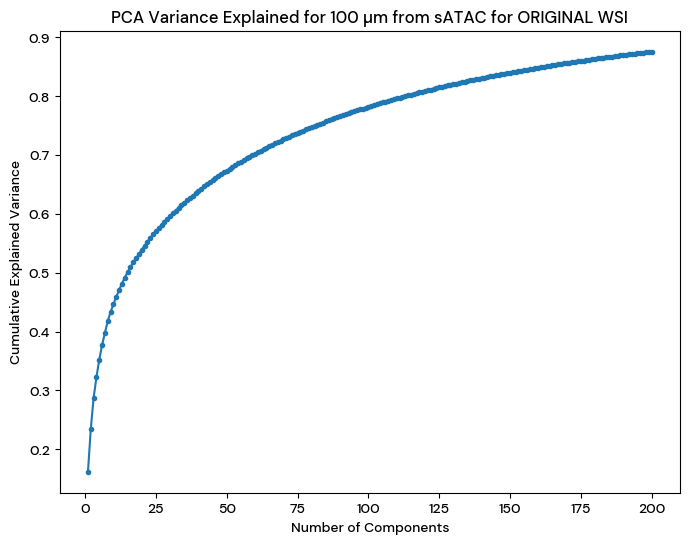

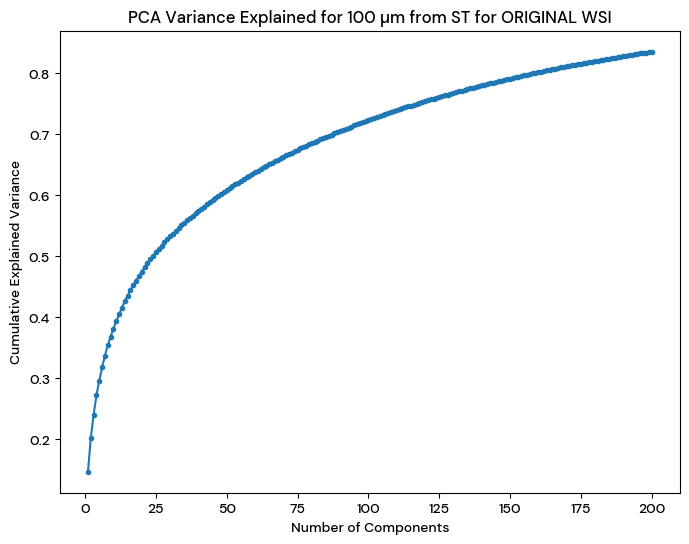

In [42]:
from utils_clust_n_class import pca_single_cumulative_variance_plot

for sample in selected_100um_pickles:
    
    plot = pca_single_cumulative_variance_plot(sample, selected_100um_pickles, NORMALISATION_NAME, TILE_SIZE, n_comp=200)
    plot.show()

200 Components are enough.

## 2.3 - Clustering on selected PCs

Selecting the previously stated amount of PCs.

In [43]:
components_per_method_100um = {}
NUMBER_OF_COMPONENTS_100 = 200

In [44]:
for sample in selected_100um_pickles:
    model = PCA(n_components=NUMBER_OF_COMPONENTS_100)
    
    # saving the first n components in a dataframe maintaining the same indeces
    components_per_method_100um[f"First {NUMBER_OF_COMPONENTS_100} PC for {sample}"] = pd.DataFrame(model.fit_transform(selected_100um_pickles[sample]), 
                                                                                                index=selected_100um_pickles[sample].index)

# components_per_method_100um

Selecting the number of clusters.

In [45]:
# Perform clustering and store results
cluster_labels_n_colors_100um = {}

For sample: First 200 PC for satac_C1_&_v3_allspots_&_target_is_reference_full_100um_ORIGINAL WSI.pickle
Number of Leiden clusters: [0 1 2 3]


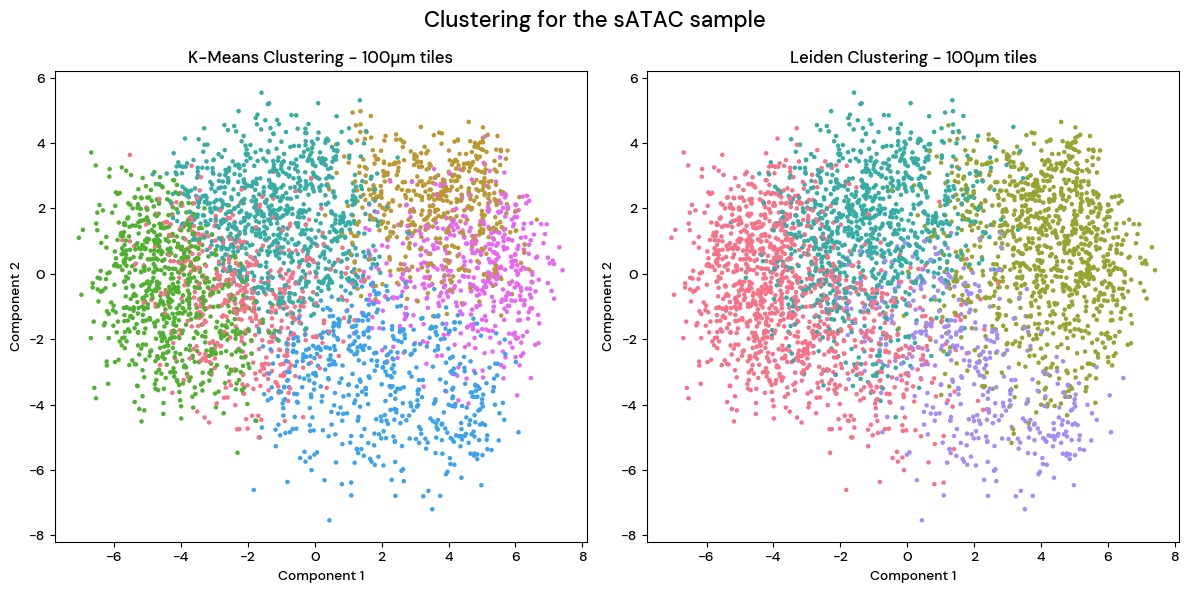

For sample: First 200 PC for visium_FFPE_dcis_idc_10X_&_img_not_changed_allspots_&_target_is_reference_full_100um_ORIGINAL WSI.pickle
Number of Leiden clusters: [0 1 2 3 4 5]


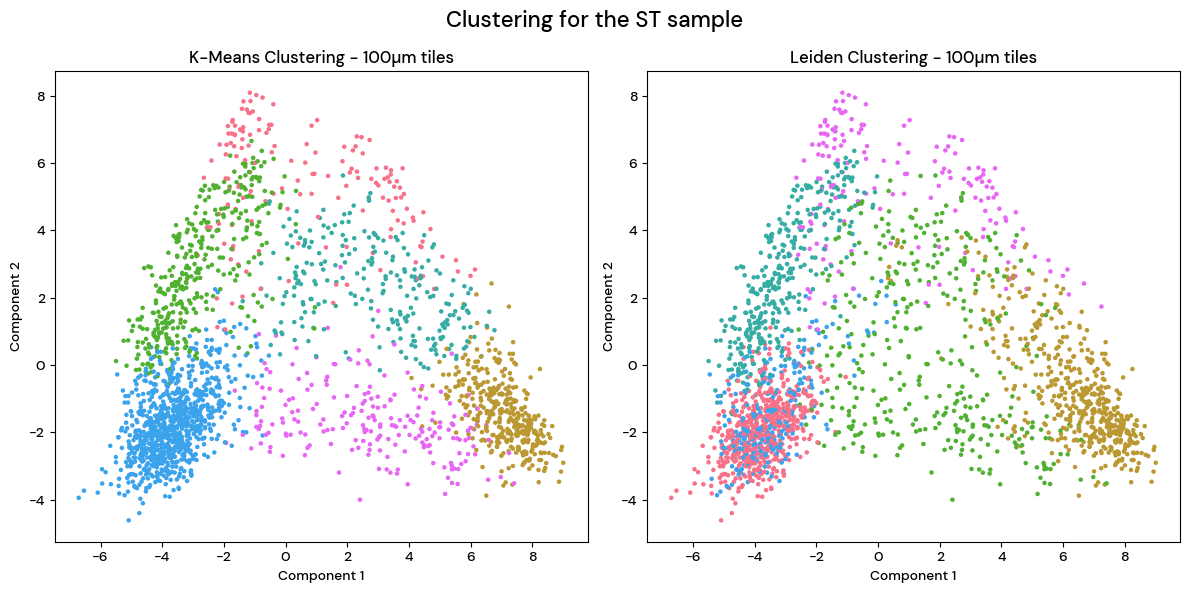

In [46]:
# from utils_clust_n_class import single_clustering_by_method
from utils_clust_n_class import single_clustering_by_method_v2

for sample, pca_df in components_per_method_100um.items():
    print("For sample:", sample)
    fig, cluster_labels_n_colors_100um[sample] = single_clustering_by_method_v2(
        sample,
        selected_components=pca_df, 
        n_clust=NUMBER_OF_CLUSTERS, 
        TILE_SIZE=TILE_SIZE, 
        selected_methods=["K-Means", "Leiden"], # "K-Means", "HDBSCAN", "Agglomerative", "Leiden"
        leiden_resolution = 0.4
    )
    fig.savefig(os.path.join(PATH_TO_FIGURES, 
                             f"clustering_plots_{NUMBER_OF_CLUSTERS}_clusters_{sample.split('for ')[-1].strip('.pickle')}.pdf"), 
                format="PDF", bbox_inches="tight")

Structure of the output dictionary:

In [47]:
for name, dict_ in cluster_labels_n_colors_100um.items():
    print('\n\nFor element:', name, "\nWe have the following methods:\n", dict_.keys())




For element: First 200 PC for satac_C1_&_v3_allspots_&_target_is_reference_full_100um_ORIGINAL WSI.pickle 
We have the following methods:
 dict_keys(['K-Means', 'Leiden'])


For element: First 200 PC for visium_FFPE_dcis_idc_10X_&_img_not_changed_allspots_&_target_is_reference_full_100um_ORIGINAL WSI.pickle 
We have the following methods:
 dict_keys(['K-Means', 'Leiden'])


## 2.4 - Plotting the clusters on WSI

For sample: First 200 PC for satac_C1_&_v3_allspots_&_target_is_reference_full_100um_ORIGINAL WSI.pickle


Original size: (47616, 48128), Rescaled size: (1979, 2000)
Original size: (47616, 48128), Rescaled size: (1979, 2000)


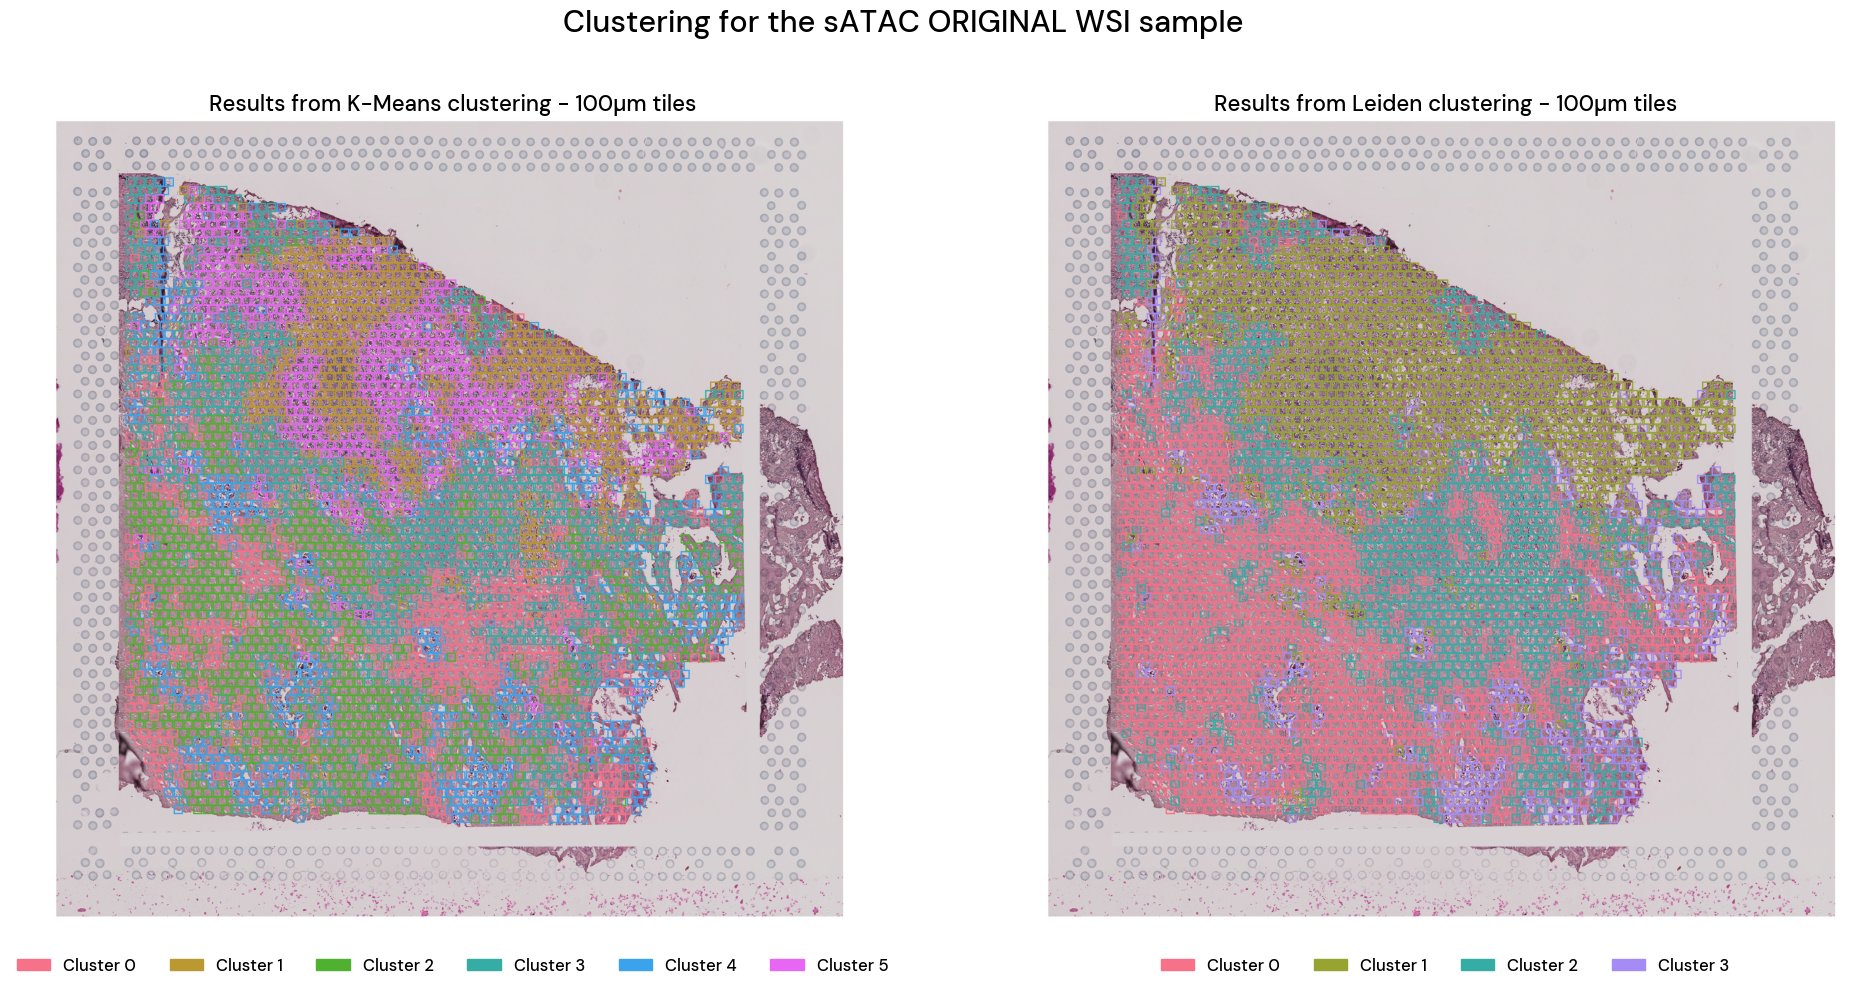

For sample: First 200 PC for visium_FFPE_dcis_idc_10X_&_img_not_changed_allspots_&_target_is_reference_full_100um_ORIGINAL WSI.pickle
Original size: (27452, 25233), Rescaled size: (2176, 2000)
Original size: (27452, 25233), Rescaled size: (2176, 2000)


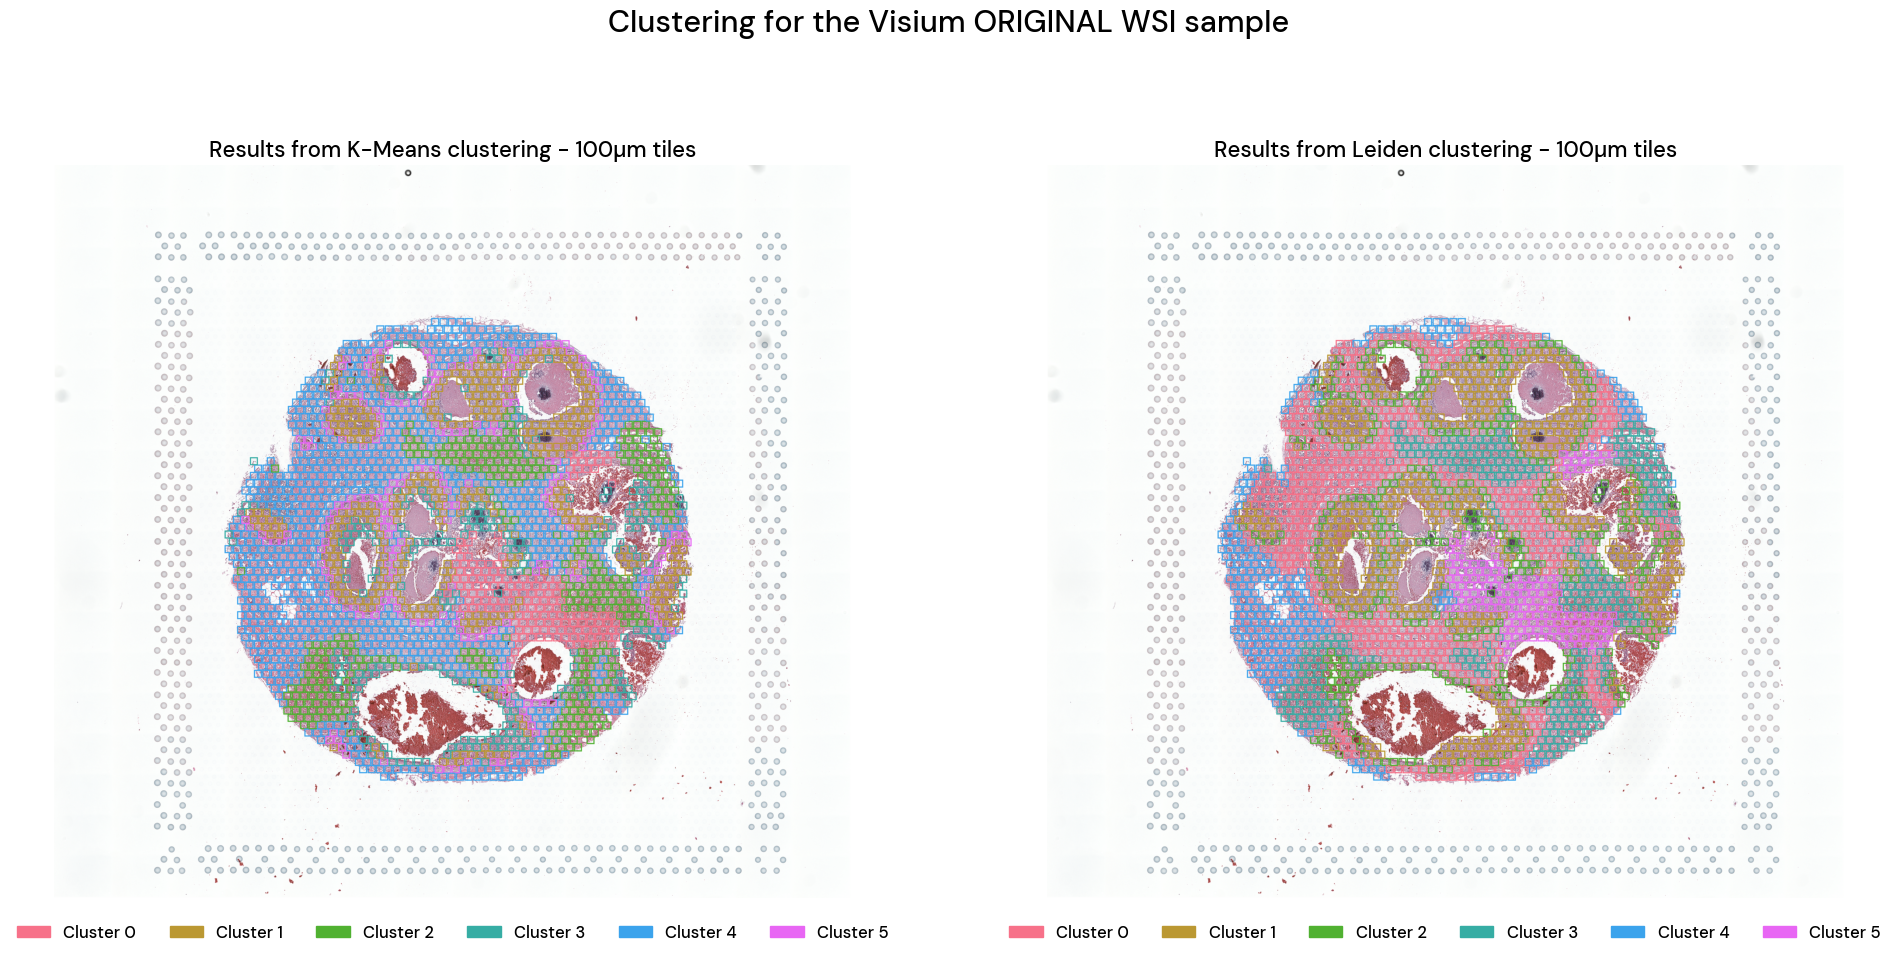

In [48]:
from utils_clust_n_class import draw_tiles_on_wsi


for sample, all_clustering in cluster_labels_n_colors_100um.items():
    print("For sample:", sample)
    #print(all_clustering.items())
    if "satac" in sample:
        
        draw_tiles_on_wsi(satac_wsi,
                            satac_coord_df,
                            all_clustering,
                            "sATAC",
                            TILE_SIZE,
                            NORMALISATION_NAME,
                            shape_to_plot = "rectangle",
                            atac_px_size = satac_scale_factor_tile_size,
                            saving_path = os.path.join(PATH_TO_FIGURES, 
                                                       f"plotted_{NUMBER_OF_CLUSTERS}_clusters_on_wsi_{sample.split('for ')[-1].strip('.pickle')}.pdf")
                         )

    if "visium" in sample:
        
        draw_tiles_on_wsi(visium_wsi,
                            visium_coord_df,
                            all_clustering,
                            "visium",
                            TILE_SIZE, # this must refer to the value of the scale factor for the tile size, not the spot one
                            NORMALISATION_NAME,
                            shape_to_plot = "rectangle",
                            visium_px_size = visium_scale_factor_tile_size,
                            saving_path = os.path.join(PATH_TO_FIGURES, 
                                                       f"plotted_{NUMBER_OF_CLUSTERS}_clusters_on_wsi_{sample.split('for ')[-1].strip('.pickle')}.pdf")
                         )

## 2.5 - Saving the clusters

In [49]:
from utils_clust_n_class import saving_obtained_clusters

for sample, all_clustering in cluster_labels_n_colors_100um.items():
    print("For sample:", sample)
    #print(all_clustering.items())
    if "satac" in sample:
        for clustering_name, df_cluster_colors in all_clustering.items():
            saving_obtained_clusters(
                                    satac_coord_df,
                                    df_cluster_colors,
                                    saving_path = os.path.join(PATH_TO_SAVING_OUTPUT, 
                                                            f"tissue_position_list_with_{NUMBER_OF_CLUSTERS}_{clustering_name.lower().replace('-', '')}_clusters_{sample.split('for ')[-1].strip('.pickle')}.csv")
                            )

    if "visium" in sample:
        for clustering_name, df_cluster_colors in all_clustering.items():
            saving_obtained_clusters(
                                    visium_coord_df,
                                    df_cluster_colors,
                                    saving_path = os.path.join(PATH_TO_SAVING_OUTPUT, 
                                                            f"tissue_position_list_with_{NUMBER_OF_CLUSTERS}_{clustering_name.lower().replace('-', '')}_clusters_{sample.split('for ')[-1].strip('.pickle')}.csv")
                            )

For sample: First 200 PC for satac_C1_&_v3_allspots_&_target_is_reference_full_100um_ORIGINAL WSI.pickle
Saving at:
 output/UNI2-h/satac_C1_v3_allspots_&_visium_FFPE_dcis_idc_10X_img_not_changed_allspots/on_individual_samples/6_clusters/tissue_position_list_with_6_kmeans_clusters_satac_C1_&_v3_allspots_&_target_is_reference_full_100um_ORIGINAL WSI.csv
Saving at:
 output/UNI2-h/satac_C1_v3_allspots_&_visium_FFPE_dcis_idc_10X_img_not_changed_allspots/on_individual_samples/6_clusters/tissue_position_list_with_6_leiden_clusters_satac_C1_&_v3_allspots_&_target_is_reference_full_100um_ORIGINAL WSI.csv
For sample: First 200 PC for visium_FFPE_dcis_idc_10X_&_img_not_changed_allspots_&_target_is_reference_full_100um_ORIGINAL WSI.pickle
Saving at:
 output/UNI2-h/satac_C1_v3_allspots_&_visium_FFPE_dcis_idc_10X_img_not_changed_allspots/on_individual_samples/6_clusters/tissue_position_list_with_6_kmeans_clusters_visium_FFPE_dcis_idc_10X_&_img_not_changed_allspots_&_target_is_reference_full_100um_OR

---

# 3. - For 68 μm tiles

## 3.1 - Importing .pickle files of features

In [50]:
from utils_clust_n_class import load_pickle_as_df

selected_68um_pickles = {}

for pkl in selected_pickle_names:
    if "68um" in pkl:
        selected_68um_pickles[pkl] = load_pickle_as_df(os.path.join(PATH_TO_SINGLE_PICKLES, pkl)).T

print(selected_68um_pickles.keys())

dict_keys(['satac_C1_&_v3_allspots_&_target_is_reference_full_68um_ORIGINAL WSI.pickle', 'visium_FFPE_dcis_idc_10X_&_img_not_changed_allspots_&_target_is_reference_full_68um_ORIGINAL WSI.pickle'])


### 3.1.1 - Excluding eventual necrosis-associated tiles

In [51]:
for sample in selected_68um_pickles:
    if sample.startswith("visium"):
        print("Sample name:", sample)
        print("Shape of the features dataframe:", selected_68um_pickles[sample].shape)

if PATH_TO_VISIUM_NECROSIS_SELECTED_SPOTS:
    
    necrosis_df = pd.read_csv(PATH_TO_VISIUM_NECROSIS_SELECTED_SPOTS, names=["barcode", "spot_cluster"], skiprows=1)
    print("Shape of the necrosis tiles dataframe:",necrosis_df.shape)
    
    necrosis_barcodes = set(necrosis_df["barcode"])  # Convert to set for fast lookup

    for sample in selected_68um_pickles:
        if sample.startswith("visium"):
            df = selected_68um_pickles[sample]
            df["just_barcodes"] = df.index.str.split("_").str[0]  # Extract barcode prefix

            # Filter out rows where barcode is in necrosis_barcodes
            temp = df[~df["just_barcodes"].isin(necrosis_barcodes)].copy()
            temp.drop(columns=["just_barcodes"], inplace=True)  # Drop helper column

            selected_68um_pickles[sample] = temp
            
            print("Shape of the features dataframe after removing the necrosis spots:", temp.shape)


Sample name: visium_FFPE_dcis_idc_10X_&_img_not_changed_allspots_&_target_is_reference_full_68um_ORIGINAL WSI.pickle
Shape of the features dataframe: (2518, 1536)
Shape of the necrosis tiles dataframe: (310, 2)
Shape of the features dataframe after removing the necrosis spots: (2208, 1536)


## 3.2 - Dimensionality reduction

Let's plot the cumulative variance explained by the most important components.

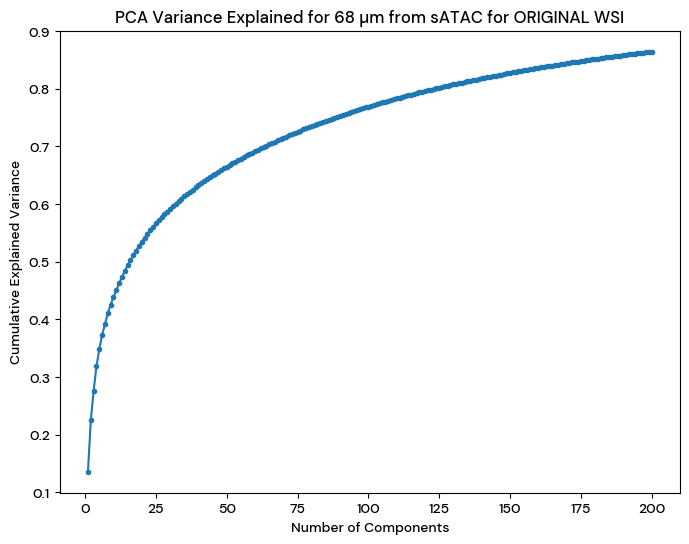

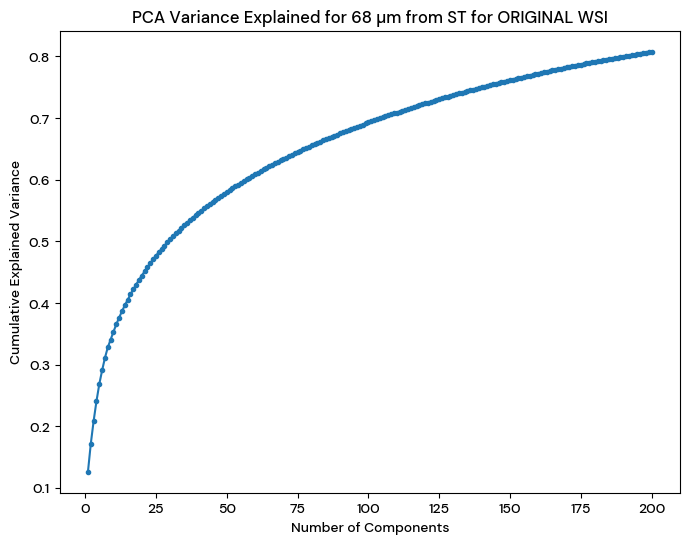

In [52]:
from utils_clust_n_class import pca_single_cumulative_variance_plot

for sample in selected_68um_pickles:
    
    plot = pca_single_cumulative_variance_plot(sample, selected_68um_pickles, NORMALISATION_NAME, SPOT_SIZE, n_comp=200)
    plot.show()

200 Components are enough.

## 3.3 - Clustering on selected PCs

Selecting the previously stated amount of PCs.

In [53]:
components_per_method_68um = {}
NUMBER_OF_COMPONENTS_68 = 200

In [54]:
for sample in selected_68um_pickles:
    model = PCA(n_components=NUMBER_OF_COMPONENTS_68)
    
    # saving the first n components in a dataframe maintaining the same indeces
    components_per_method_68um[f"First {NUMBER_OF_COMPONENTS_68} PC for {sample}"] = pd.DataFrame(model.fit_transform(selected_68um_pickles[sample]), 
                                                                                                index=selected_68um_pickles[sample].index)

# components_per_method_68um

In [55]:
# Perform clustering and store results
cluster_labels_n_colors_68um = {}

For sample: First 200 PC for satac_C1_&_v3_allspots_&_target_is_reference_full_68um_ORIGINAL WSI.pickle


Number of Leiden clusters: [0 1 2 3 4]


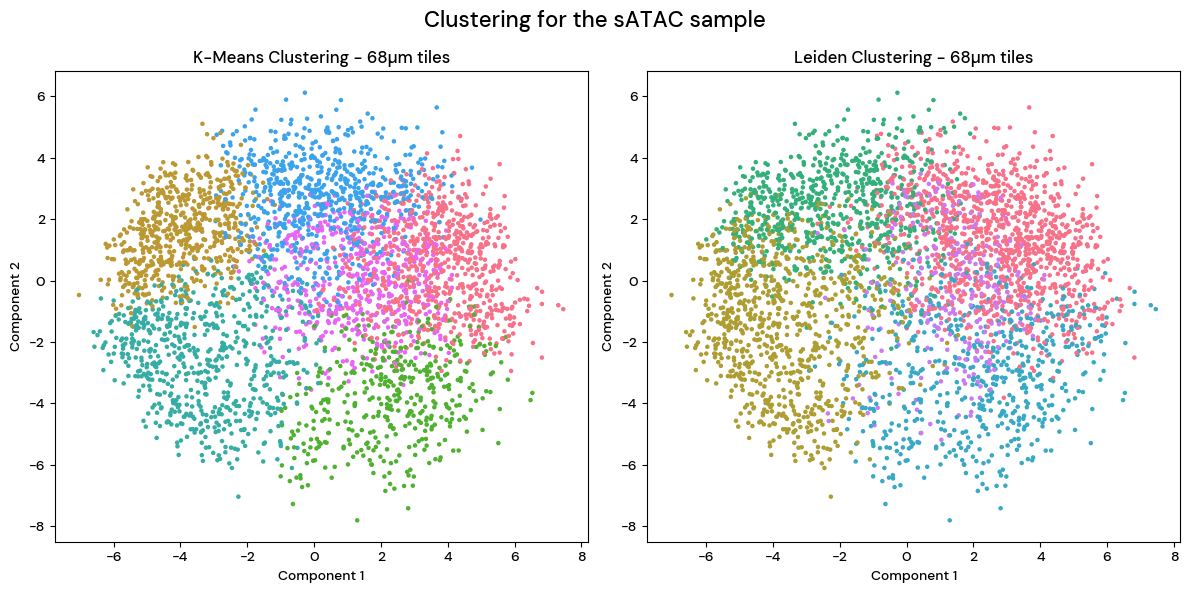

For sample: First 200 PC for visium_FFPE_dcis_idc_10X_&_img_not_changed_allspots_&_target_is_reference_full_68um_ORIGINAL WSI.pickle
Number of Leiden clusters: [0 1 2 3 4 5 6]


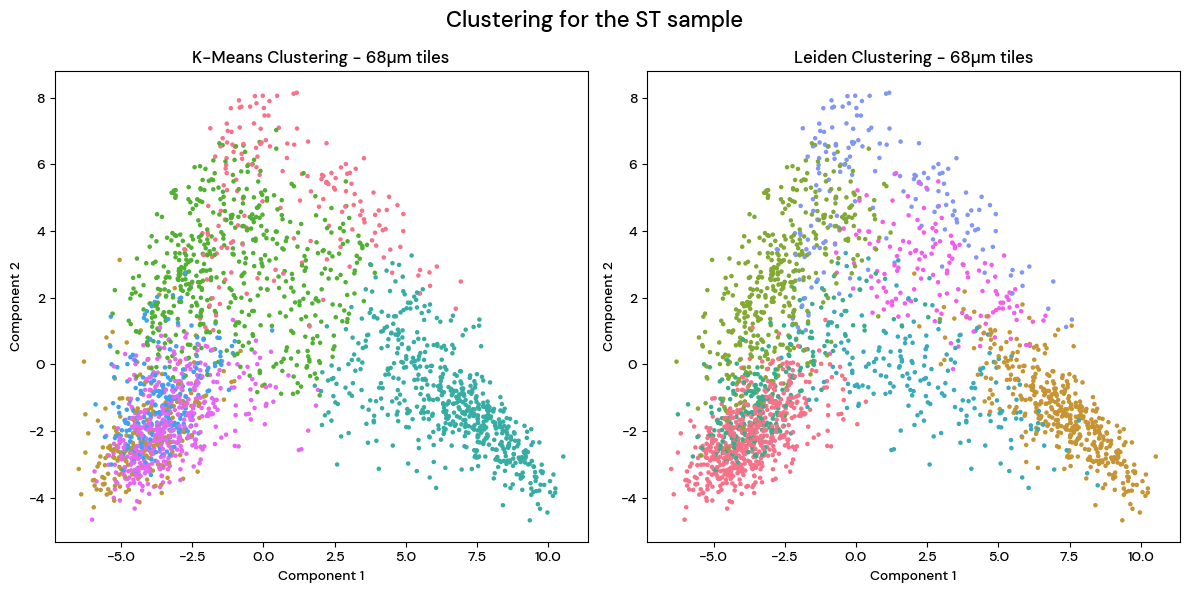

In [56]:
# from utils_clust_n_class import single_clustering_by_method
from utils_clust_n_class import single_clustering_by_method_v2

for sample, pca_df in components_per_method_68um.items():
    print("For sample:", sample)
    fig, cluster_labels_n_colors_68um[sample] = single_clustering_by_method_v2(
        sample,
        selected_components=pca_df, 
        n_clust=NUMBER_OF_CLUSTERS, 
        TILE_SIZE=SPOT_SIZE, 
        selected_methods=["K-Means", "Leiden"], # "HDBSCAN",
        leiden_resolution= 0.5
    )
    fig.savefig(os.path.join(PATH_TO_FIGURES, 
                             f"clustering_plots_{NUMBER_OF_CLUSTERS}_clusters_{sample.split('for ')[-1].strip('.pickle')}.pdf"), 
                format="PDF", bbox_inches="tight")

Structure of the output dictionary:

In [57]:
for name, dict_ in cluster_labels_n_colors_68um.items():
    print('\n\nFor element:', name, "\nWe have the following methods:\n", dict_.keys())




For element: First 200 PC for satac_C1_&_v3_allspots_&_target_is_reference_full_68um_ORIGINAL WSI.pickle 
We have the following methods:
 dict_keys(['K-Means', 'Leiden'])


For element: First 200 PC for visium_FFPE_dcis_idc_10X_&_img_not_changed_allspots_&_target_is_reference_full_68um_ORIGINAL WSI.pickle 
We have the following methods:
 dict_keys(['K-Means', 'Leiden'])


## 3.4 - Plotting the clusters on WSI

For sample: First 200 PC for satac_C1_&_v3_allspots_&_target_is_reference_full_68um_ORIGINAL WSI.pickle
Original size: (47616, 48128), Rescaled size: (1979, 2000)
Original size: (47616, 48128), Rescaled size: (1979, 2000)


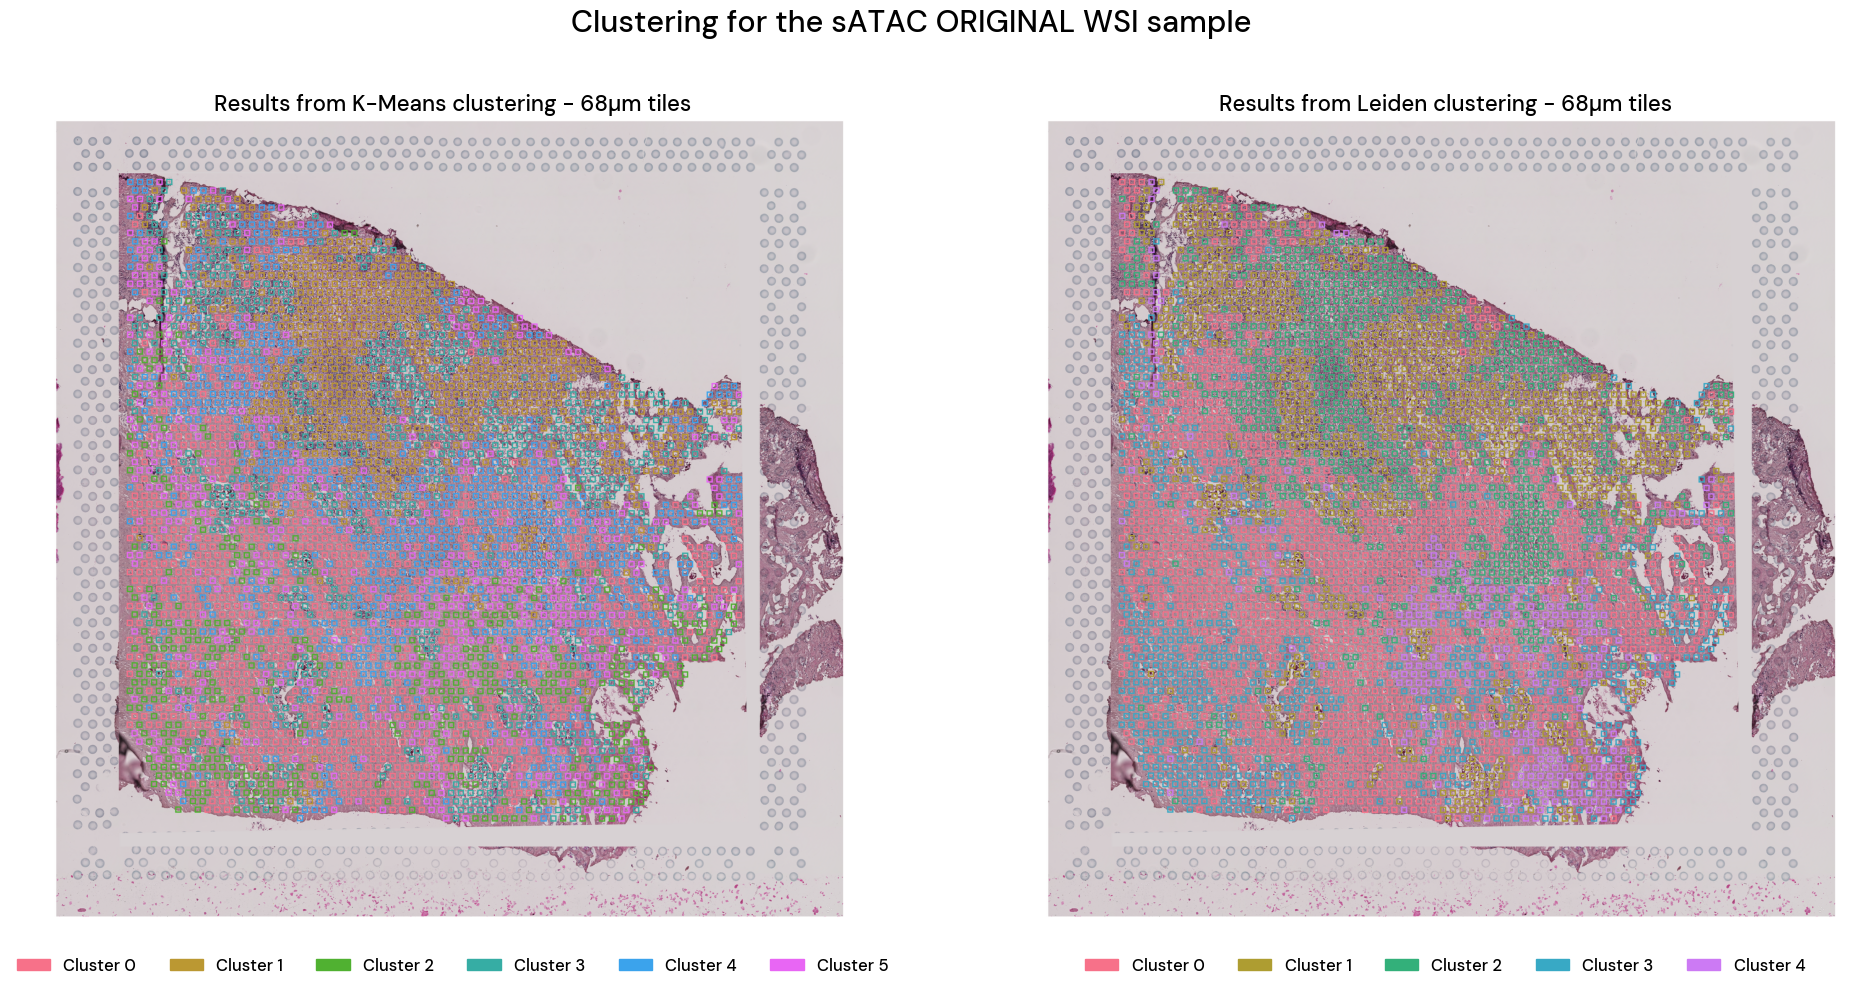

For sample: First 200 PC for visium_FFPE_dcis_idc_10X_&_img_not_changed_allspots_&_target_is_reference_full_68um_ORIGINAL WSI.pickle
Original size: (27452, 25233), Rescaled size: (2176, 2000)
Original size: (27452, 25233), Rescaled size: (2176, 2000)


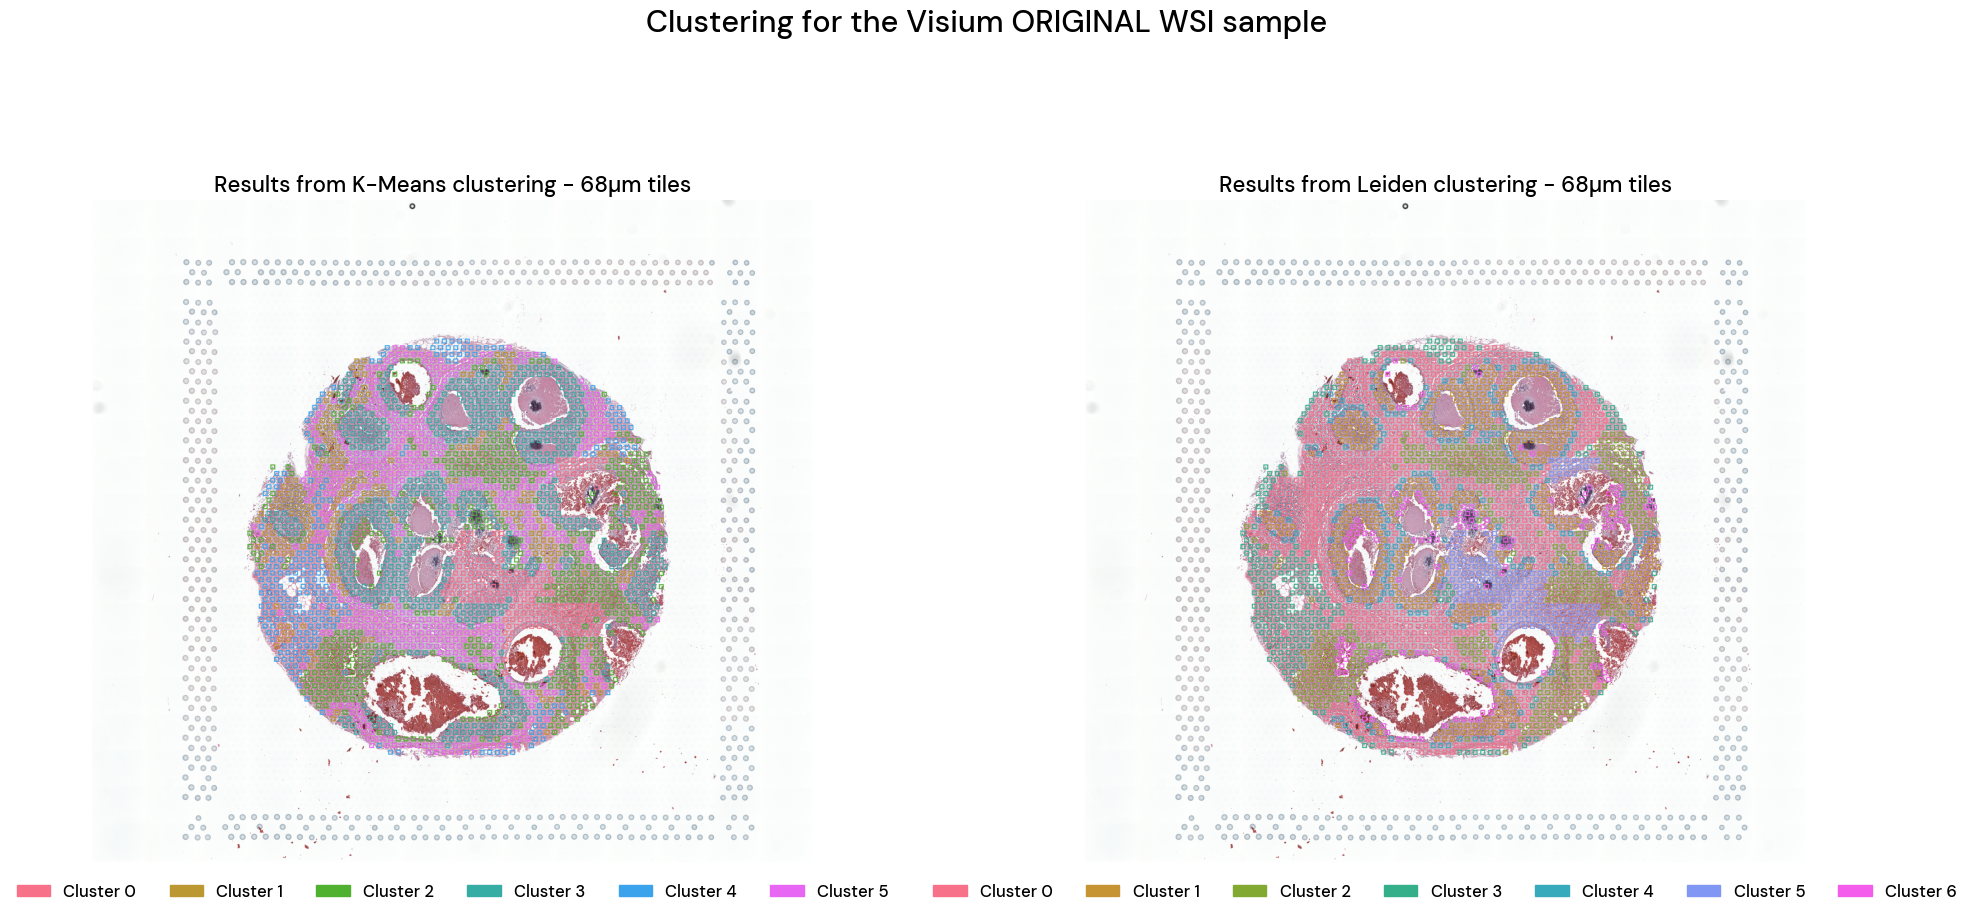

In [58]:
from utils_clust_n_class import draw_tiles_on_wsi

for sample, all_clustering in cluster_labels_n_colors_68um.items():
    print("For sample:", sample)
    #print(all_clustering.items())
    if "satac" in sample:
        
        draw_tiles_on_wsi(satac_wsi,
                            satac_coord_df,
                            all_clustering,
                            "sATAC",
                            SPOT_SIZE,
                            NORMALISATION_NAME,
                            shape_to_plot = "rectangle",
                            atac_px_size = satac_scale_factor_spot_size,
                            saving_path = os.path.join(PATH_TO_FIGURES, 
                                                       f"plotted_{NUMBER_OF_CLUSTERS}_clusters_on_wsi_{sample.split('for ')[-1].strip('.pickle')}.pdf")
                         )

    if "visium" in sample:
        
        draw_tiles_on_wsi(visium_wsi,
                            visium_coord_df,
                            all_clustering,
                            "visium",
                            SPOT_SIZE, # this must refer to the value of the scale factor for the tile size, not the spot one
                            NORMALISATION_NAME,
                            shape_to_plot = "rectangle",
                            visium_px_size = visium_scale_factor_spot_size,
                            saving_path = os.path.join(PATH_TO_FIGURES, 
                                                       f"plotted_{NUMBER_OF_CLUSTERS}_clusters_on_wsi_{sample.split('for ')[-1].strip('.pickle')}.pdf")
                         )

## 3.5 - Saving the clusters

In [59]:
from utils_clust_n_class import saving_obtained_clusters

for sample, all_clustering in cluster_labels_n_colors_68um.items():
    print("For sample:", sample)
    #print(all_clustering.items())
    if "satac" in sample:
        for clustering_name, df_cluster_colors in all_clustering.items():
            saving_obtained_clusters(
                                    satac_coord_df,
                                    df_cluster_colors,
                                    saving_path = os.path.join(PATH_TO_SAVING_OUTPUT, 
                                                            f"tissue_position_list_with_{NUMBER_OF_CLUSTERS}_{clustering_name.lower().replace('-', '')}_clusters_{sample.split('for ')[-1].strip('.pickle')}.csv")
                            )

    if "visium" in sample:
        for clustering_name, df_cluster_colors in all_clustering.items():
            saving_obtained_clusters(
                                    visium_coord_df,
                                    df_cluster_colors,
                                    saving_path = os.path.join(PATH_TO_SAVING_OUTPUT, 
                                                            f"tissue_position_list_with_{NUMBER_OF_CLUSTERS}_{clustering_name.lower().replace('-', '')}_clusters_{sample.split('for ')[-1].strip('.pickle')}.csv")
                            )

For sample: First 200 PC for satac_C1_&_v3_allspots_&_target_is_reference_full_68um_ORIGINAL WSI.pickle
Saving at:
 output/UNI2-h/satac_C1_v3_allspots_&_visium_FFPE_dcis_idc_10X_img_not_changed_allspots/on_individual_samples/6_clusters/tissue_position_list_with_6_kmeans_clusters_satac_C1_&_v3_allspots_&_target_is_reference_full_68um_ORIGINAL WSI.csv
Saving at:
 output/UNI2-h/satac_C1_v3_allspots_&_visium_FFPE_dcis_idc_10X_img_not_changed_allspots/on_individual_samples/6_clusters/tissue_position_list_with_6_leiden_clusters_satac_C1_&_v3_allspots_&_target_is_reference_full_68um_ORIGINAL WSI.csv
For sample: First 200 PC for visium_FFPE_dcis_idc_10X_&_img_not_changed_allspots_&_target_is_reference_full_68um_ORIGINAL WSI.pickle
Saving at:
 output/UNI2-h/satac_C1_v3_allspots_&_visium_FFPE_dcis_idc_10X_img_not_changed_allspots/on_individual_samples/6_clusters/tissue_position_list_with_6_kmeans_clusters_visium_FFPE_dcis_idc_10X_&_img_not_changed_allspots_&_target_is_reference_full_68um_ORIGINA